# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint

In [ ]:
#@title Explanation Video
from IPython.display import HTML

HTML("""<video width="854" and height="480" controls>
  <source src="https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Walkthrough/Hackathon_Voice_based.mp4" type="video/mp4">
</video>
""")

# Hackathon: Voice commands based E-commerce ordering system
The goal of the hackathon is to train your model on different types of voice data (such as studio data and your own team data) and able to place order based on user preferences.

## Grading = 40 Marks

### **Objectives:**

Stage 0 - Obtain Features from Audio samples

Stage 1 (22 Marks) - Define and train a CNN model on Studio data and deploy the model in the server

Stage 2 (18 Marks) - Collect your voice samples (team data) and refine the classifier trained on Studio_data. Deploy the model in the server.

## Dataset Description

The data contains voice samples of classes - Zero, One, Two, Three, Four, Five. Each class is denoted by a numerical label from 0 to 5.

The audio files collected in a Studio dataset contain very few noise samples and all the files are in wav format.

The audio files recorded for the studio are saved with the following naming convention:

● Class Representation + user_id + sample_ID (or noise + sample_ID)

> For example: The voice sample by the user b2 recorded “Zero”, it is saved as 0_b2_35.wav. Here 35 is sample ID, 2 is the user id and ‘0’ is the label of that sample.




In [1]:
#@title Please run the setup to download the dataset

from IPython import get_ipython
ipython = get_ipython()

notebook= "Hackathon2 - Voice E-commerce Ordering System" #name of the notebook

def setup():
    ipython.magic("sx wget https://cdn.iiith.talentsprint.com/aiml/Hackathon_data/B17_studio_rev_data.zip")
    ipython.magic("sx unzip B17_studio_rev_data.zip ")
    print ("Setup completed successfully")

setup()

Setup completed successfully


In [2]:
import os
import sys
import glob
import torch
import librosa
import warnings
import numpy as np
import torch.nn as nn
from time import sleep
from torch import optim
import torch.nn.functional as F
from torch.autograd import Variable
warnings.filterwarnings('ignore')

Audio data preprocessing

In [4]:
import os
import glob
import pandas as pd

# Path to the studio_data folder
studio_data_path = './studio_data'

# List all .wav files in the studio_data directory
wav_files = glob.glob(os.path.join(studio_data_path, '*.wav'))

# Prepare lists to store extracted data
data = []

for filepath in wav_files:
    filename = os.path.basename(filepath)
    # Example filename: 0_b2_35.wav
    parts = filename.split('_')

    if len(parts) >= 3: # Ensure enough parts to extract class and user_id
        class_label = parts[0]
        user_id = parts[1]
        sample_id = parts[2].split('.')[0] # Remove .wav extension
        data.append({'class': class_label, 'user_id': user_id, 'sample_id': sample_id})
    else:
        print(f"Skipping file due to unexpected naming convention: {filename}")

# Create a pandas DataFrame from the extracted data
df = pd.DataFrame(data)

# Calculate counts of samples per class and user_id
counts = df.groupby(['user_id', 'class']).size().unstack(fill_value=0)

print("Counts of samples per class and user_id:")
print(counts)

# Optionally, check if each user has data for all 5 classes (0-4 or 0-5 depending on definition)
# The example implies 0-5 (6 classes: Zero to Five)
expected_classes = [str(i) for i in range(6)] # Assuming classes '0' through '5'

# Check for missing classes per user
missing_classes_per_user = {}
for user in counts.index:
    user_classes = counts.loc[user].index.astype(str).tolist()
    missing = [c for c in expected_classes if c not in user_classes]
    if missing:
        missing_classes_per_user[user] = missing

if missing_classes_per_user:
    print("\nUsers with missing classes:")
    for user, missing in missing_classes_per_user.items():
        print(f"User {user} is missing data for classes: {', '.join(missing)}")
else:
    print("\nAll users have data for all expected classes (0-5).")

Counts of samples per class and user_id:
class        0    1    2    3    4    5
user_id                                
B1           0    1    0    0    0    0
G10         10   10   10    9   10   10
G11          8   10   10   10   10   10
G12         10   10   10   10   10   10
G13         10   10   10   10   10   10
G14          8    9    9    8    4   10
G15          9   10   10   10   10   10
G16          9    8    9    9   10   10
G17         10   10   10   10    9   10
G18          9   10   10    8   10   10
G19         10   10   10   10   10   10
G2          10   10   10   10   10   10
G3          10   10   10   10   10   10
G4           9   10   10   10    9   10
G5           9    9   10   10   10   10
G6          10   10   10   10   10   10
G7           9   10    9    9    8   10
G8          10   10   10    9    9   10
G9           9    9   10   10   10   10
R2           0    0    1    0    0    0
a1           7    8    9    8    8    7
a1           0    1    0    0    0    0

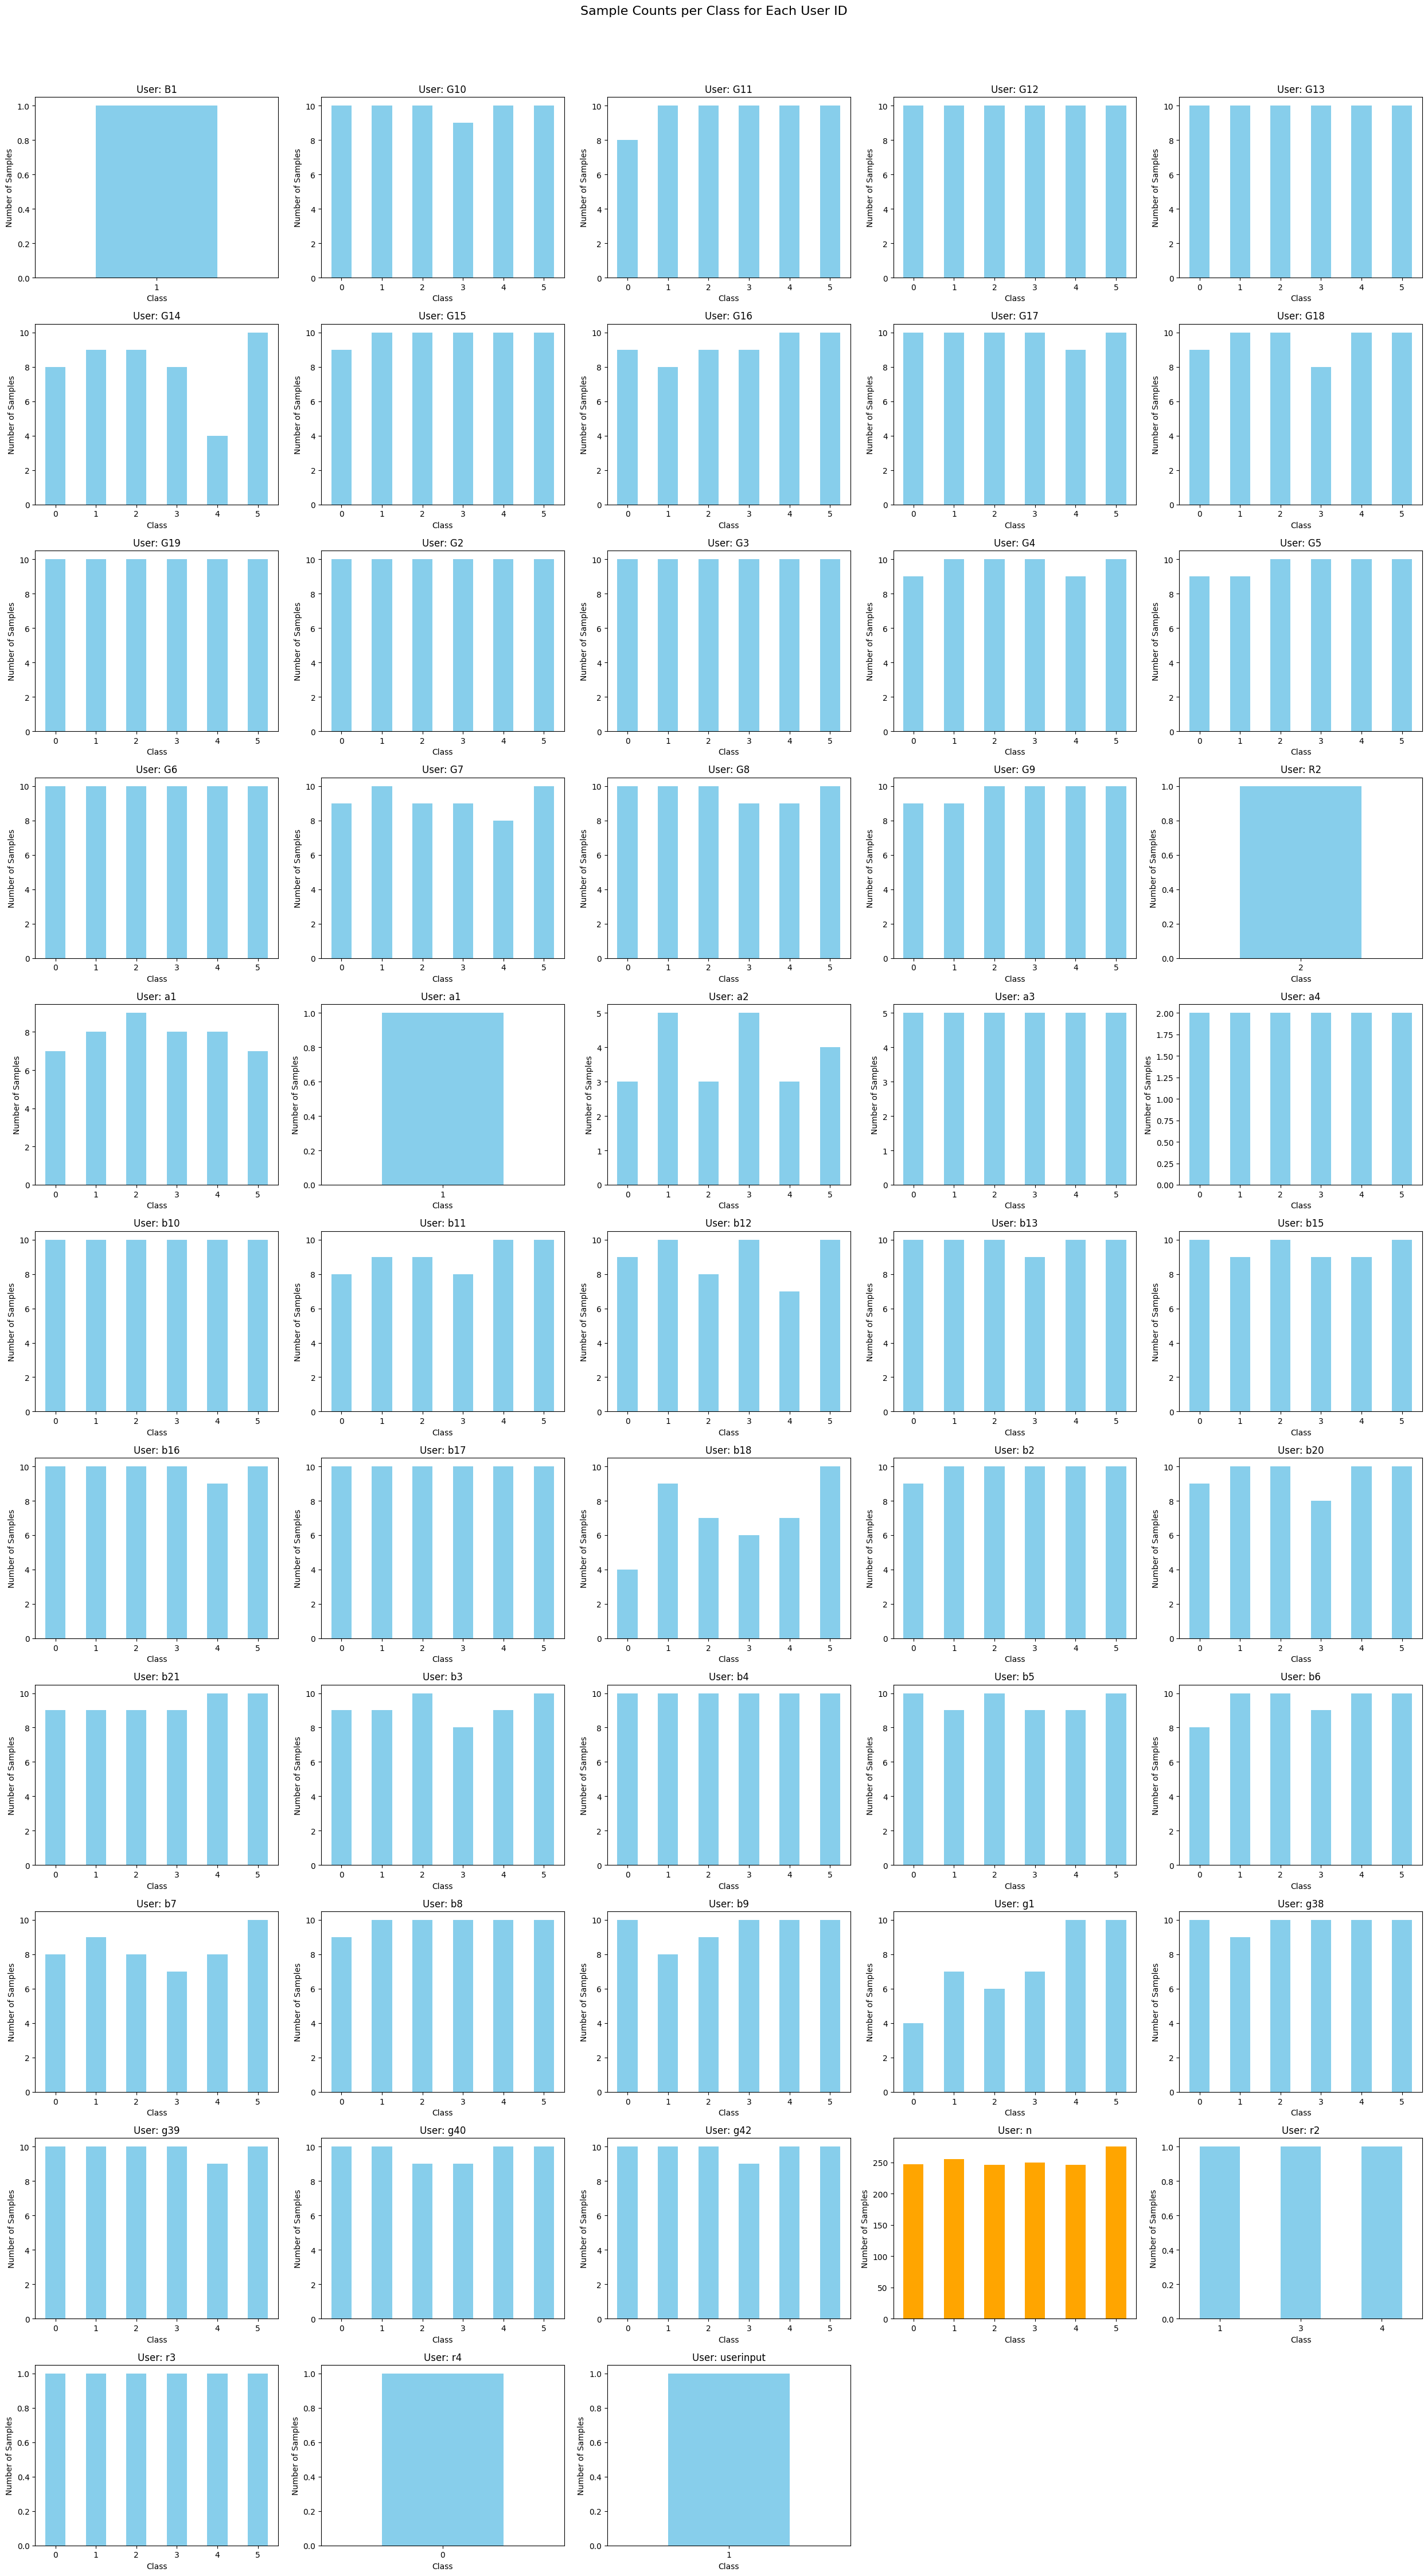

In [5]:
import matplotlib.pyplot as plt
import math

# Assuming 'counts' DataFrame is available from the previous cell
# If not, you might need to re-run the previous cell or ensure 'counts' is globally accessible.

if 'counts' in locals() or 'counts' in globals():
    num_users = len(counts)
    ncols = 5 # Number of columns for subplots
    nrows = math.ceil(num_users / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
    fig.suptitle('Sample Counts per Class for Each User ID', fontsize=16, y=1.02)
    axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

    for i, (user_id, row) in enumerate(counts.iterrows()):
        ax = axes[i]
        # Highlight user 'n' with a different color
        bar_color = 'skyblue'
        if user_id == 'n':
            bar_color = 'orange' # Distinct color for user 'n'

        row[row > 0].plot(kind='bar', ax=ax, color=bar_color) # Plot only classes with counts > 0
        ax.set_title(f'User: {user_id}')
        ax.set_xlabel('Class')
        ax.set_ylabel('Number of Samples')
        ax.tick_params(axis='x', rotation=0) # Keep x-axis labels horizontal
        ax.set_ylim(bottom=0) # Ensure y-axis starts from 0

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("Error: The 'counts' DataFrame was not found. Please run the previous cell first.")

In [25]:
"""
Notebook-friendly version — no argparse, just edit the variables below
and run the cell. Paste this whole thing into a Colab cell.
"""

import os
import glob
import shutil
import random
from collections import defaultdict

# ---- EDIT THESE ----
#data_dir = './studio_data'
#data_dir='./flagged_samples'
data_dir='./studio_data_excluded_silence'                                 # folder with .wav files
users_to_check = ['n', 'B1', 'R2', 'r2', 'r3', 'r4', 'userinput']  # user_ids to inspect
sample_size = 300                                          # None/0 = copy all matches
out_dir = './to_listen'
list_only = False                                             # True = just print counts, no copying
seed = 42
# ---------------------


def parse_filename(filename):
    parts = os.path.splitext(filename)[0].split('_')
    if len(parts) < 3:
        return None, None, None
    return parts[0], parts[1], parts[2]


wav_files = glob.glob(os.path.join(data_dir, '*.wav'))
print(f"Found {len(wav_files)} wav files in {data_dir}")

by_user = defaultdict(list)
unparsed = []
for fp in wav_files:
    label, user_id, sample_id = parse_filename(os.path.basename(fp))
    if user_id is None:
        unparsed.append(fp)
    else:
        by_user[user_id].append(fp)

if unparsed:
    print(f"\n{len(unparsed)} files didn't match the <label>_<user>_<id>.wav pattern:")
    for fp in unparsed:
        print("  ", os.path.basename(fp))

if list_only:
    print("\nCounts per user_id:")
    for user_id, files in sorted(by_user.items(), key=lambda kv: -len(kv[1])):
        print(f"  {user_id:12s} {len(files)}")
else:
    random.seed(seed)
    os.makedirs(out_dir, exist_ok=True)

    for user_id in users_to_check:
        files = by_user.get(user_id, [])
        if not files:
            print(f"\nuser_id '{user_id}': no files found")
            continue

        chosen = files
        if sample_size and sample_size < len(files):
            chosen = random.sample(files, sample_size)

        print(f"\nuser_id '{user_id}': {len(files)} total, copying {len(chosen)}")
        for fp in chosen:
            dest = os.path.join(out_dir, os.path.basename(fp))
            shutil.copy2(fp, dest)
            print("  ->", dest)

    print(f"\nDone. Files copied to: {out_dir}")

Found 322 wav files in ./studio_data_excluded_silence

user_id 'n': 211 total, copying 211
  -> ./to_listen/5_n_g7_100.wav
  -> ./to_listen/4_n_g2_27.wav
  -> ./to_listen/4_n_g7_39.wav
  -> ./to_listen/2_n_g24_13.wav
  -> ./to_listen/3_n_g7_110.wav
  -> ./to_listen/3_n_g4_50.wav
  -> ./to_listen/1_n_g4_72.wav
  -> ./to_listen/0_n_g4_45.wav
  -> ./to_listen/1_n_g13_0.wav
  -> ./to_listen/5_n_g7_76.wav
  -> ./to_listen/1_n_g24_96.wav
  -> ./to_listen/5_n_g2_100.wav
  -> ./to_listen/3_n_g4_38.wav
  -> ./to_listen/2_n_g7_85.wav
  -> ./to_listen/3_n_g5_2.wav
  -> ./to_listen/5_n_g8_40.wav
  -> ./to_listen/1_n_g12_60.wav
  -> ./to_listen/0_n_g2_105.wav
  -> ./to_listen/0_n_b4_9.wav
  -> ./to_listen/2_n_g2_97.wav
  -> ./to_listen/4_n_g22_3.wav
  -> ./to_listen/1_n_g3_0.wav
  -> ./to_listen/5_n_g7_52.wav
  -> ./to_listen/1_n_g7_84.wav
  -> ./to_listen/4_n_g4_87.wav
  -> ./to_listen/3_n_g13_26.wav
  -> ./to_listen/1_n_b1_48.wav
  -> ./to_listen/1_n_g12_72.wav
  -> ./to_listen/1_n_g2_84.wav
  ->

In [27]:
from IPython.display import Audio, display
import glob

for fp in sorted(glob.glob('/content/studio_data/0_G10_105.wav')):
    print(fp)
    display(Audio(fp))

/content/studio_data/0_G10_105.wav


In [6]:
import os
import glob
import shutil
import argparse
import numpy as np
import librosa
import pandas as pd

# ---- defaults (edit these if running as a notebook cell) ----
DATA_DIR = './studio_data'
REVIEW_DIR = './flagged_samples'
SNR_THRESH_DB = 15.0        # below this -> no clear speech burst above background
ACTIVE_RATIO_THRESH = 0.10  # below this -> too little "active" signal
FRAME_LEN = 256
HOP = 128
# ---------------------------------------------------------------


def compute_metrics(y):
    rms = float(np.sqrt(np.mean(y ** 2)))
    peak = float(np.max(np.abs(y)))
    flatness = float(np.mean(librosa.feature.spectral_flatness(y=y)))

    energies = np.array([
        np.sqrt(np.mean(y[j:j + FRAME_LEN] ** 2))
        for j in range(0, max(len(y) - FRAME_LEN, 1), HOP)
    ])
    floor = np.percentile(energies, 20)
    peak_e = np.percentile(energies, 95)
    snr_db = float(20 * np.log10((peak_e + 1e-8) / (floor + 1e-8)))
    active_ratio = float(np.mean(energies > floor * 3))

    return {
        'rms': rms,
        'peak': peak,
        'flatness': flatness,
        'snr_db': snr_db,
        'active_ratio': active_ratio,
    }


def parse_filename(filename):
    parts = os.path.splitext(filename)[0].split('_')
    if len(parts) < 3:
        return None, None, None
    return parts[0], parts[1], parts[2]


def scan_folder(data_dir, sr=8000):
    wav_files = sorted(glob.glob(os.path.join(data_dir, '*.wav')))
    rows = []
    for fp in wav_files:
        fname = os.path.basename(fp)
        label, user_id, sample_id = parse_filename(fname)
        y, _ = librosa.load(fp, sr=sr)
        m = compute_metrics(y)
        m.update({
            'filepath': fp,
            'filename': fname,
            'label': label,
            'user_id': user_id,
            'sample_id': sample_id,
        })
        rows.append(m)
    return pd.DataFrame(rows)


def flag_bad_samples(df, snr_thresh=SNR_THRESH_DB, active_ratio_thresh=ACTIVE_RATIO_THRESH):
    df = df.copy()
    df['flagged'] = (df['snr_db'] < snr_thresh) | (df['active_ratio'] < active_ratio_thresh)
    return df


def run(data_dir=DATA_DIR, review_dir=REVIEW_DIR,
        snr_thresh=SNR_THRESH_DB, active_ratio_thresh=ACTIVE_RATIO_THRESH,
        copy_flagged=True, csv_out='sample_quality_report.csv'):

    print(f"Scanning {data_dir} ...")
    df_metrics = scan_folder(data_dir)
    print(f"Loaded {len(df_metrics)} files")

    df_metrics = flag_bad_samples(df_metrics, snr_thresh, active_ratio_thresh)
    df_metrics.sort_values('snr_db', inplace=True)

    df_metrics.to_csv(csv_out, index=False)
    print(f"Full report written to {csv_out}")

    flagged = df_metrics[df_metrics['flagged']]
    print(f"\nFlagged {len(flagged)} / {len(df_metrics)} files as silent/low-quality "
          f"(SNR < {snr_thresh} dB or active_ratio < {active_ratio_thresh})")

    if len(flagged):
        print("\nWorst offenders (lowest SNR):")
        print(flagged[['filename', 'user_id', 'label', 'snr_db', 'active_ratio']]
              .head(20).to_string(index=False))

        print("\nFlagged counts by user_id:")
        print(flagged['user_id'].value_counts())

        if copy_flagged:
            os.makedirs(review_dir, exist_ok=True)
            for fp in flagged['filepath']:
                shutil.copy2(fp, os.path.join(review_dir, os.path.basename(fp)))
            print(f"\nCopied {len(flagged)} flagged files to {review_dir} for spot-checking")

    return df_metrics


if __name__ == '__main__':
    ap = argparse.ArgumentParser()
    ap.add_argument('--data_dir', default=DATA_DIR)
    ap.add_argument('--review_dir', default=REVIEW_DIR)
    ap.add_argument('--snr_thresh', type=float, default=SNR_THRESH_DB)
    ap.add_argument('--active_ratio_thresh', type=float, default=ACTIVE_RATIO_THRESH)
    ap.add_argument('--no_copy', action='store_true')
    ap.add_argument('--csv_out', default='sample_quality_report.csv')
    args, _unknown = ap.parse_known_args()   # parse_known_args -> safe under Colab launcher too

    # Assign the returned DataFrame to the global 'df' variable
    df = run(
        data_dir=args.data_dir,
        review_dir=args.review_dir,
        snr_thresh=args.snr_thresh,
        active_ratio_thresh=args.active_ratio_thresh,
        copy_flagged=not args.no_copy,
        csv_out=args.csv_out,
    )

Scanning ./studio_data ...
Loaded 3979 files
Full report written to sample_quality_report.csv

Flagged 347 / 3979 files as silent/low-quality (SNR < 15.0 dB or active_ratio < 0.1)

Worst offenders (lowest SNR):
      filename user_id label   snr_db  active_ratio
  2_G14_73.wav     G14     2 2.752080      0.018519
 0_n_g4_33.wav       n     0 2.995781      0.000000
  0_G7_105.wav      G7     0 3.004361      0.000000
1_n_g23_60.wav       n     1 3.142583      0.000000
  3_G14_74.wav     G14     3 3.219433      0.037037
  5_G14_76.wav     G14     5 3.427426      0.000000
5_n_g4_100.wav       n     5 3.683406      0.000000
 1_n_g8_36.wav       n     1 3.738662      0.000000
1_n_g8_108.wav       n     1 3.801837      0.000000
  1_n_g2_0.wav       n     1 3.977848      0.000000
 0_n_g12_9.wav       n     0 4.093791      0.000000
4_n_g23_75.wav       n     4 4.151309      0.000000
5_n_g7_112.wav       n     5 4.298218      0.000000
5_n_g23_88.wav       n     5 4.633616      0.000000
   1_b7_6

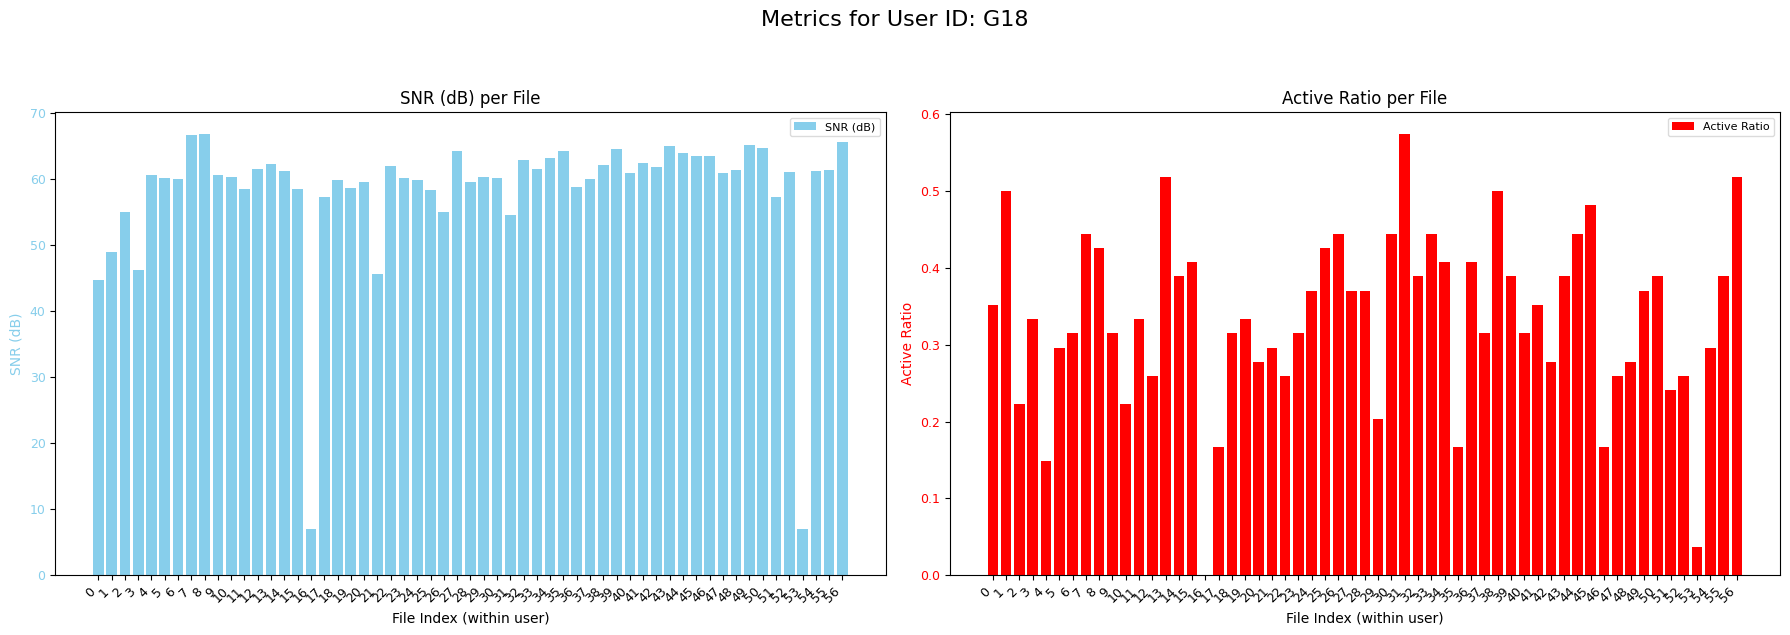

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd

# df is available from the execution of cell 6ojIc_TnDwg_

# User can change this to explore different users
selected_user_id = 'G18'

if 'df' in locals() or 'df' in globals():
    # Filter DataFrame for the selected user
    user_df = df[df['user_id'] == selected_user_id].sort_values(by='sample_id').reset_index(drop=True)

    if user_df.empty:
        print(f"No data found for user_id: {selected_user_id}")
    else:
        # Create a figure with two subplots (1 row, 2 columns)
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
        fig.suptitle(f'Metrics for User ID: {selected_user_id}', fontsize=16, y=1.05)

        snr_color = 'skyblue'
        active_ratio_color = 'red'
        # Optional: Add specific highlighting if selected_user_id is 'n'
        if selected_user_id == 'n':
            for ax in axes:
                ax.set_facecolor('#FFFACD') # Light yellow background for user 'n'
            snr_color = 'dodgerblue' # Slightly different blue
            active_ratio_color = 'darkorange' # Orange for active ratio

        # Plot SNR in the first subplot
        ax1 = axes[0]
        ax1.bar(user_df.index, user_df['snr_db'], color=snr_color, width=0.8, label='SNR (dB)')
        ax1.set_xlabel('File Index (within user)', fontsize=10)
        ax1.set_ylabel('SNR (dB)', color=snr_color, fontsize=10)
        ax1.tick_params(axis='y', labelcolor=snr_color, labelsize=9)
        ax1.tick_params(axis='x', labelsize=9)
        ax1.set_xticks(user_df.index)
        ax1.set_xticklabels(user_df.index, rotation=45, ha='right') # Rotate x-labels for readability
        ax1.set_title('SNR (dB) per File', fontsize=12)
        ax1.set_ylim(bottom=0) # Ensure y-axis starts from 0 for SNR
        ax1.legend(loc='upper right', fontsize=8, framealpha=0.7)

        # Plot Active Ratio in the second subplot
        ax2 = axes[1]
        ax2.bar(user_df.index, user_df['active_ratio'], color=active_ratio_color, width=0.8, label='Active Ratio')
        ax2.set_xlabel('File Index (within user)', fontsize=10)
        ax2.set_ylabel('Active Ratio', color=active_ratio_color, fontsize=10)
        ax2.tick_params(axis='y', labelcolor=active_ratio_color, labelsize=9)
        ax2.tick_params(axis='x', labelsize=9)
        ax2.set_xticks(user_df.index)
        ax2.set_xticklabels(user_df.index, rotation=45, ha='right') # Rotate x-labels for readability
        ax2.set_title('Active Ratio per File', fontsize=12)
        ax2.set_ylim(bottom=0) # Ensure y-axis starts from 0 for Active Ratio
        ax2.legend(loc='upper right', fontsize=8, framealpha=0.7)

        plt.tight_layout()
        plt.subplots_adjust(top=0.88) # Adjust top to prevent suptitle overlap
        plt.show()
else:
    print("Error: The 'df' DataFrame was not found. Please run the cell that generates it first (e.g., cell 6ojIc_TnDwg_).")

### Distinguish truly silent files from noisy-but-real speech, then remove only the silent ones

In [8]:
# Burst detection: distinguish TRULY SILENT files from files that are
# noisy but still contain real speech (like your r3 "noise with numbers"
# sample). We only want to remove the former from studio_data.
#
# Reuses the flagged rows already computed in `df` from the previous cell
# -- only re-loads audio for files that were actually flagged, not the
# whole dataset again.

def detect_burst(y, frame_len=FRAME_LEN, hop=HOP,
                  local_snr_thresh_db=10.0, min_peak_amp=0.08):
    """
    True if a real speech-like burst exists, even amid background noise.
    Looks for a LOCAL peak that stands out from ITS OWN surrounding floor,
    rather than comparing to the whole-clip average like the SNR flag does.
    """
    energies = np.array([
        np.sqrt(np.mean(y[j:j + frame_len] ** 2))
        for j in range(0, max(len(y) - frame_len, 1), hop)
    ])
    if len(energies) < 5:
        return False

    peak_idx = int(np.argmax(energies))
    peak_val = energies[peak_idx]

    window = 5
    mask = np.ones(len(energies), dtype=bool)
    mask[max(0, peak_idx - window):peak_idx + window] = False
    floor = np.median(energies[mask]) if mask.sum() > 0 else np.median(energies)

    local_snr_db = 20 * np.log10((peak_val + 1e-8) / (floor + 1e-8))
    abs_peak_amp = float(np.max(np.abs(y)))

    return (local_snr_db > local_snr_thresh_db) and (abs_peak_amp > min_peak_amp)


flagged_mask = df['flagged']
has_burst_col = []

for idx, row in df.iterrows():
    if row['flagged']:
        y, _ = librosa.load(row['filepath'], sr=8000)
        has_burst_col.append(detect_burst(y))
    else:
        has_burst_col.append(True)   # not flagged at all -> treat as fine

df['has_burst'] = has_burst_col
# flagged AND no burst -> truly silent -> quarantine
# flagged but HAS a burst -> noisy but real speech -> keep
# not flagged at all -> keep
df['action'] = np.where(df['flagged'] & ~df['has_burst'], 'quarantine', 'keep')

to_quarantine = df[df['action'] == 'quarantine']
kept_but_noisy = df[df['flagged'] & (df['action'] == 'keep')]

print(f"{len(to_quarantine)} / {len(df)} files: TRULY SILENT -> will be quarantined")
print(f"{len(kept_but_noisy)} / {len(df)} files: noisy but real speech -> KEEPING")
print()
print("Quarantine candidates by user_id:")
print(to_quarantine['user_id'].value_counts())
print()
print("Preview of quarantine candidates (lowest SNR first):")
print(to_quarantine[['filename', 'user_id', 'label', 'snr_db', 'active_ratio']]
      .sort_values('snr_db').head(20).to_string(index=False))


322 / 3979 files: TRULY SILENT -> will be quarantined
25 / 3979 files: noisy but real speech -> KEEPING

Quarantine candidates by user_id:
user_id
n            211
g1            28
b21           11
b10            8
b20            7
b7             6
b8             5
g39            4
b18            4
G14            4
g40            3
b3             3
b15            3
G4             3
b5             3
b4             2
G16            2
b16            2
g42            2
G18            2
b6             2
userinput      1
G7             1
G5             1
G15            1
a1             1
b2             1
b9             1
Name: count, dtype: int64

Preview of quarantine candidates (lowest SNR first):
      filename user_id label   snr_db  active_ratio
  2_G14_73.wav     G14     2 2.752080      0.018519
 0_n_g4_33.wav       n     0 2.995781      0.000000
  0_G7_105.wav      G7     0 3.004361      0.000000
1_n_g23_60.wav       n     1 3.142583      0.000000
  3_G14_74.wav     G14     3 3.219433

In [9]:
# Actually move the truly-silent files OUT of studio_data.
# MOVE, not delete -- fully reversible if you need to double check later.
#
# IMPORTANT: re-run this cell only once per quarantine decision -- running
# it twice is harmless (shutil.move on an already-moved file just errors,
# doesn't duplicate), but there's no need to re-run unless you change the
# thresholds above and regenerate `to_quarantine`.

quarantine_dir = './studio_data_excluded_silence'
os.makedirs(quarantine_dir, exist_ok=True)

moved = 0
for fp in to_quarantine['filepath']:
    if os.path.exists(fp):   # skip if already moved in a prior run
        shutil.move(fp, os.path.join(quarantine_dir, os.path.basename(fp)))
        moved += 1

remaining = len(glob.glob(os.path.join(studio_data_path, '*.wav')))
print(f"Moved {moved} files to {quarantine_dir}/")
print(f"{studio_data_path} now has {remaining} files remaining for training.")


Moved 322 files to ./studio_data_excluded_silence/
./studio_data now has 3657 files remaining for training.


### Retrain Stage 1 from scratch on the cleaned dataset

Since this changes the composition of `studio_data` itself (not just adding new samples), the fix only takes effect if you retrain from scratch — go back and **re-run your Stage 1 cells in order**, starting from `load_data('./studio_data')`, through the fresh `model = Net()` (a NEW, randomly-initialized model, not loading old weights), all the way through training, testing, and saving.

Do **not** load your previous `studio_model.pth`/`speech_model.t7` and fine-tune on top of it here -- those old weights were trained on the un-cleaned data, so any bias from the removed silent files is already baked into them. A clean retrain avoids inheriting that.

After retraining, regenerate the confusion matrix from earlier and check whether:
- silence no longer defaults to predicting "1"
- the 1↔5 and 2↔4 confusion pairs improved at all (they might not fully resolve from this alone, but worth checking)


## **Stage 0:** Obtain Features from Audio samples
---

### Generate features from an audio sample of '.wav' format
- Code is available to extract the features

In [10]:
# Caution: Do not change the default parameters
def get_features(filepath, sr=8000, n_mfcc=30, n_mels=128, frames = 15):
    # The following function contains code to produce features of the audio sample.
    y, sr = librosa.load(filepath, sr=sr)
    D = np.abs(librosa.stft(y))**2
    S = librosa.feature.melspectrogram(S=D)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_S = librosa.power_to_db(S,ref=np.max)
    features = librosa.feature.mfcc(S=log_S, n_mfcc=n_mfcc)
    if features.shape[1] < frames :
        features = np.hstack((features, np.zeros((n_mfcc, frames - features.shape[1]))))
    elif features.shape[1] > frames:
        features = features[:, :frames]

    # Find 1st order delta_mfcc
    delta1_mfcc = librosa.feature.delta(features, order=1)

    # Find 2nd order delta_mfcc
    delta2_mfcc = librosa.feature.delta(features, order=2)

    # Stacking delta_mfcc features in sequence horizontally (column wise)
    features = np.hstack((delta1_mfcc.flatten(), delta2_mfcc.flatten()))

    # Increase the dimension by inserting an axis along second dimension
    features = features.flatten()[:,np.newaxis]

    # Convert the numpy.ndarray to a Tensor object
    features = Variable(torch.from_numpy(features)).float()
    return features

All the voice samples needed for training are present in the folder `"studio_data"`

In [11]:
%ls

B17_studio_rev_data.zip  sample_quality_report.csv
flagged_samples/         studio_data/
sample_data/             studio_data_excluded_silence/


##**Stage 1**:  Define and train a CNN model on Studio data and deploy the model in the server

---


### a) Extract features of Studio data (4 Marks)

 Load 'Studio data' and extract mfcc features

 **Evaluation Criteria:**

 * Complete the code in the load_data function
 * The function should take path of the folder containing audio samples as input
 * It should return features of all the audio samples present in the specified folder into single array (list of lists or 2-d numpy array) and their respective labels should be returned too

In [12]:
def load_data(folder_path):
    """
    Loads all .wav files from folder_path, extracts MFCC-based features
    using get_features(), and pulls the class label out of the filename.

    Filenames look like: 0_b2_35.wav  -> label is the first token ("0")
    """
    features = []
    labels = []

    wav_files = glob.glob(os.path.join(folder_path, '*.wav'))
    print(f"Found {len(wav_files)} wav files in {folder_path}")

    for filepath in wav_files:
        filename = os.path.basename(filepath)
        label = int(filename.split('_')[0])          # class label is the first token
        feat = get_features(filepath)                  # tensor shape (900, 1)
        features.append(feat.numpy().flatten())         # flatten to (900,)
        labels.append(label)

    features = np.array(features)   # shape (N, 900)
    labels = np.array(labels)       # shape (N,)
    return features, labels


Load data from studio_data folder for extracting all features and labels

In [13]:
studio_recorded_features, studio_recorded_labels = load_data('/content/studio_data')

Found 3657 wav files in /content/studio_data


Use train_test_split for splitting the train and test data

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    studio_recorded_features,
    studio_recorded_labels,
    test_size=0.2,
    random_state=42,
    stratify=studio_recorded_labels
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (2925, 900) Test shape: (732, 900)


Load the dataset with DataLoader
- Refer to [torch.utils.data.TensorDataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.TensorDataset)
- Refer to [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)

In [15]:
from torch.utils.data import TensorDataset, DataLoader

# Conv1d expects (batch, channels, length) -> we treat the 900 features as
# channels and use a sequence length of 1 (matches conv1's in_channels=900)
X_train_tensor = torch.from_numpy(X_train).float().unsqueeze(2)   # (N, 900, 1)
y_train_tensor = torch.from_numpy(y_train).long()

X_test_tensor = torch.from_numpy(X_test).float().unsqueeze(2)     # (N, 900, 1)
y_test_tensor = torch.from_numpy(y_test).long()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Batches per epoch (train):", len(train_loader))


Batches per epoch (train): 183


### b) Define your CNN architecture (4 Marks)

[Hint](https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html)

In [16]:
## Define your CNN Architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # Sample Convolution Layer 1
        self.conv1 = nn.Conv1d(in_channels=900, out_channels=400, kernel_size=1)
        self.bn1 = nn.BatchNorm1d(400)
        self.relu1 = nn.ReLU()

        # Sample Maxpool for the Convolutional Layer 1
        self.maxpool1 = nn.MaxPool1d(1)

        # Sample Dropout Layer
        self.dropout = nn.Dropout(p=0.25)

        # Convolutional Layer 2
        self.conv2 = nn.Conv1d(in_channels=400, out_channels=200, kernel_size=1)
        self.bn2 = nn.BatchNorm1d(200)
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool1d(1)

        # Convolutional Layer 3
        self.conv3 = nn.Conv1d(in_channels=200, out_channels=100, kernel_size=1)
        self.bn3 = nn.BatchNorm1d(100)
        self.relu3 = nn.ReLU()
        self.maxpool3 = nn.MaxPool1d(1)

        # Fully Connected Layer -> 6 classes (Zero..Five)
        self.fc1 = nn.Linear(100, 6)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        # Convolution Layer 1, Maxpool and Dropout
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.maxpool1(out)
        out = self.dropout(out)

        # Convolution Layer 2, Maxpool and Dropout
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.maxpool2(out)
        out = self.dropout(out)

        # Convolution Layer 3, Maxpool and Dropout
        out = self.conv3(out)
        out = self.bn3(out)
        out = self.relu3(out)
        out = self.maxpool3(out)
        out = self.dropout(out)

        # Flatten (batch, 100, 1) -> (batch, 100)
        out = out.view(out.size(0), -1)

        # Fully connected + LogSoftmax
        out = self.fc1(out)
        out = self.logsoftmax(out)
        return out


In [17]:
# To run the training on GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [18]:
model = Net()
model = model.to(device)
print(model)

criterion = nn.NLLLoss()                                   # pairs with LogSoftmax output
optimizer = optim.Adam(model.parameters(), lr=0.001)        # Adam generally converges fastest here


Net(
  (conv1): Conv1d(900, 400, kernel_size=(1,), stride=(1,))
  (bn1): BatchNorm1d(400, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (maxpool1): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (conv2): Conv1d(400, 200, kernel_size=(1,), stride=(1,))
  (bn2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (maxpool2): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(200, 100, kernel_size=(1,), stride=(1,))
  (bn3): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (maxpool3): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100, out_features=6, bias=True)
  (logsoftmax): LogSoftmax(dim=1)
)


### c) Train and classify on the studio_data (3 Marks)

The goal here is to train the Model on voice samples collected in studio data and validate it continuously to calculate the loss and accuracy for the train dataset across each epoch.

Iterate over images in the train_loader and perform the following steps.

1. First, zero out the gradients using zero_grad()

2. Pass the data to the model. Convert the data to GPU before passing data  to the model

3. Calculate the loss using a Loss function

4. Perform Backward pass using backward() to update the weights

5. Optimize and predict by using the torch.max()

6. Calculate the accuracy of the train dataset


In [19]:
num_epochs = 30

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()               # 1. zero out gradients
        output = model(data)                 # 2. forward pass
        loss = criterion(output, target)     # 3. compute loss
        loss.backward()                      # 4. backward pass
        optimizer.step()                     # 5. update weights

        running_loss += loss.item() * data.size(0)
        _, predicted = torch.max(output, 1)  # 6. get predicted class
        correct += (predicted == target).sum().item()
        total += target.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}  Train Accuracy: {epoch_acc:.2f}%")


Epoch [1/30]  Loss: 1.3930  Train Accuracy: 45.64%
Epoch [2/30]  Loss: 0.9760  Train Accuracy: 64.72%
Epoch [3/30]  Loss: 0.8302  Train Accuracy: 69.54%
Epoch [4/30]  Loss: 0.7769  Train Accuracy: 72.82%
Epoch [5/30]  Loss: 0.6594  Train Accuracy: 77.09%
Epoch [6/30]  Loss: 0.6340  Train Accuracy: 77.95%
Epoch [7/30]  Loss: 0.5890  Train Accuracy: 78.94%
Epoch [8/30]  Loss: 0.5305  Train Accuracy: 82.15%
Epoch [9/30]  Loss: 0.5361  Train Accuracy: 81.30%
Epoch [10/30]  Loss: 0.5126  Train Accuracy: 81.91%
Epoch [11/30]  Loss: 0.4921  Train Accuracy: 82.56%
Epoch [12/30]  Loss: 0.4527  Train Accuracy: 84.58%
Epoch [13/30]  Loss: 0.4597  Train Accuracy: 84.21%
Epoch [14/30]  Loss: 0.4290  Train Accuracy: 85.16%
Epoch [15/30]  Loss: 0.3917  Train Accuracy: 86.12%
Epoch [16/30]  Loss: 0.3886  Train Accuracy: 86.29%
Epoch [17/30]  Loss: 0.3632  Train Accuracy: 88.44%
Epoch [18/30]  Loss: 0.3591  Train Accuracy: 87.93%
Epoch [19/30]  Loss: 0.3470  Train Accuracy: 87.93%
Epoch [20/30]  Loss: 

### d) Testing Evaluation for CNN model (3 Marks)

Evaluate model with the given test data

1. Transform and load the test images.

2. Pass the test data through the model (network) to get the outputs

3. Get the predictions from a maximum value using torch.max

4. Compare with the actual labels and get the count of the correct labels

5. Calculate the accuracy based on the count of correct labels

### **Expected testing accuracy is above 80%**

In [20]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

test_accuracy = 100.0 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 88.11%


In [22]:
# Paste as a new cell. Tests ONE audio file against your already-trained
# `model`, showing not just the predicted digit but the full confidence
# breakdown across all 6 classes -- this is what actually tells you whether
# cleaning helped, since a silent file will ALWAYS get assigned to some
# digit (LogSoftmax guarantees that) -- what matters is HOW confidently.

import torch
import numpy as np

def test_single_file(filepath, model, device):
    features = get_features(filepath)            # (900, 1)
    features = features.unsqueeze(0).to(device)   # (1, 900, 1) -- add batch dim

    model.eval()
    with torch.no_grad():
        output = model(features)          # log-probabilities, shape (1, 6)
        probs = torch.exp(output)         # convert LogSoftmax -> actual probabilities
        predicted = torch.argmax(output, dim=1).item()
        confidence = probs.max().item()

    print(f"File: {filepath}")
    print(f"Predicted digit: {predicted}")
    print(f"Confidence (top class probability): {confidence:.3f}")
    print(f"Uniform/random baseline would be: {1/6:.3f}")
    print()
    print("Full probability breakdown:")
    for digit, p in enumerate(probs[0].cpu().numpy()):
        bar = '#' * int(p * 50)
        print(f"  digit_{digit}: {p:.3f}  {bar}")

    return predicted, confidence, probs[0].cpu().numpy()


# --- Usage ---
# Point this at one of your known silent files (upload it first if it's
# not already on disk in this Colab session, e.g. via the Files panel).
silent_file_path = '/content/studio_data_excluded_silence/0_G7_105.wav'   # <-- change to your actual silent file's path

test_single_file(silent_file_path, model, device)

File: /content/studio_data_excluded_silence/0_G7_105.wav
Predicted digit: 2
Confidence (top class probability): 0.863
Uniform/random baseline would be: 0.167

Full probability breakdown:
  digit_0: 0.045  ##
  digit_1: 0.047  ##
  digit_2: 0.863  ###########################################
  digit_3: 0.010  
  digit_4: 0.014  
  digit_5: 0.021  #


(2,
 0.86277174949646,
 array([0.04508507, 0.04670511, 0.86277175, 0.00987856, 0.01410597,
        0.02145355], dtype=float32))

In [31]:
# Confirms whether the classify_input() std-based guard (threshold=4.0)
# would actually catch THIS specific silent file, since it's a different
# clip than the two we originally calibrated the threshold on.

test_file = '/content/studio_data_excluded_silence/1_b5_12.wav'

feat = get_features(test_file)
feat_np = feat.detach().cpu().numpy()

feature_std = np.std(feat_np)
print(f"File: {test_file}")
print(f"Feature std: {feature_std:.3f}")
print(f"Guard threshold: 4.0")
print(f"Would be caught by guard: {feature_std < 4.0}")

File: /content/studio_data_excluded_silence/1_b5_12.wav
Feature std: 5.036
Guard threshold: 4.0
Would be caught by guard: False


In [29]:
stds = []
for fp in glob.glob('/content/studio_data_excluded_silence/*.wav'):
    feat = get_features(fp)
    stds.append(np.std(feat.detach().cpu().numpy()))

stds = np.array(stds)
print(f"Quarantined files: {len(stds)}")
print(f"std range: {stds.min():.3f} to {stds.max():.3f}")
print(f"Files that would slip PAST the guard (std >= 4.0): {(stds >= 4.0).sum()}")

Quarantined files: 322
std range: 0.444 to 5.036
Files that would slip PAST the guard (std >= 4.0): 11


In [30]:
# Part 1: identify exactly which 11 files slip past the guard, so you can
# spot-check by listening whether they're genuinely silent or were
# mistakenly quarantined (i.e. they actually contain faint real speech).

quarantine_stds = []
quarantine_files = []
for fp in glob.glob('/content/studio_data_excluded_silence/*.wav'):
    feat = get_features(fp)
    quarantine_stds.append(np.std(feat.detach().cpu().numpy()))
    quarantine_files.append(fp)

quarantine_stds = np.array(quarantine_stds)
quarantine_files = np.array(quarantine_files)

outlier_mask = quarantine_stds >= 4.0
outlier_files = quarantine_files[outlier_mask]
outlier_stds = quarantine_stds[outlier_mask]

order = np.argsort(-outlier_stds)  # highest std first (most likely to be real speech)
print("Files that slip past the guard (std >= 4.0), highest std first:")
for fp, s in zip(outlier_files[order], outlier_stds[order]):
    print(f"  {s:.3f}  {fp}")

print("\nListen to a few of these (especially the highest std ones) -- if they")
print("sound like real speech, they were mistakenly quarantined, not a guard gap.")


# Part 2: proper threshold calibration using FULL distributions, not just
# 2 examples. Compares std across ALL real training data vs ALL quarantined
# (silent) data, so you can pick a threshold based on where they actually
# separate -- not a guess.

real_stds = []
for fp in glob.glob('/content/studio_data/*.wav'):   # the CLEANED, kept files
    feat = get_features(fp)
    real_stds.append(np.std(feat.detach().cpu().numpy()))
real_stds = np.array(real_stds)

print(f"\n=== Full distribution comparison ===")
print(f"Real speech (n={len(real_stds)}):       "
      f"min={real_stds.min():.3f}  p5={np.percentile(real_stds,5):.3f}  "
      f"median={np.median(real_stds):.3f}")
print(f"Quarantined/silent (n={len(quarantine_stds)}): "
      f"max={quarantine_stds.max():.3f}  p95={np.percentile(quarantine_stds,95):.3f}  "
      f"median={np.median(quarantine_stds):.3f}")

# How many real speech files would get WRONGLY flagged at different thresholds?
for thresh in [4.0, 4.5, 5.0, 5.5]:
    false_positive_rate = (real_stds < thresh).mean()   # real speech caught by guard (bad)
    false_negative_rate = (quarantine_stds >= thresh).mean()  # silence that slips through (bad)
    print(f"\nThreshold={thresh}:")
    print(f"  Real speech wrongly flagged as silence: {false_positive_rate*100:.2f}%")
    print(f"  Silent files that slip past the guard:   {false_negative_rate*100:.2f}%")

Files that slip past the guard (std >= 4.0), highest std first:
  5.036  /content/studio_data_excluded_silence/1_b5_12.wav
  4.889  /content/studio_data_excluded_silence/0_b18_45.wav
  4.788  /content/studio_data_excluded_silence/2_G14_73.wav
  4.687  /content/studio_data_excluded_silence/0_g39_69.wav
  4.541  /content/studio_data_excluded_silence/4_b20_51.wav
  4.538  /content/studio_data_excluded_silence/5_n_g16_16.wav
  4.439  /content/studio_data_excluded_silence/5_b20_40.wav
  4.242  /content/studio_data_excluded_silence/3_b7_38.wav
  4.128  /content/studio_data_excluded_silence/0_n_b1_21.wav
  4.089  /content/studio_data_excluded_silence/0_b15_117.wav
  4.007  /content/studio_data_excluded_silence/1_b10_12.wav

Listen to a few of these (especially the highest std ones) -- if they
sound like real speech, they were mistakenly quarantined, not a guard gap.

=== Full distribution comparison ===
Real speech (n=3657):       min=1.161  p5=2.528  median=5.222
Quarantined/silent (n=322): 

In [45]:
from IPython.display import Audio, display
import glob

for fp in sorted(glob.glob('/content/studio_data_excluded_silence/0_b15_117.wav')):
    print(fp)
    display(Audio(fp))

/content/studio_data_excluded_silence/0_b15_117.wav


In [21]:
# Add this as a new cell right after your existing test-evaluation cell.
# It tells you EXACTLY what's being confused with what, instead of guessing.

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

cm = confusion_matrix(all_targets, all_preds)
print("Confusion matrix (rows = true label, columns = predicted label):")
print(cm)
print()
print(classification_report(all_targets, all_preds, digits=3,
                             target_names=[f"digit_{i}" for i in range(6)]))

# Also print actual TRAIN split counts per class -- confirms whether stratify
# actually kept things balanced in YOUR specific split, not just overall.
import collections
print("\nTrain split class counts:", collections.Counter(y_train.tolist()))
print("Test split class counts: ", collections.Counter(y_test.tolist()))

Confusion matrix (rows = true label, columns = predicted label):
[[111   0   3   1   2   1]
 [  1  96   3   0   4  16]
 [  6   3 107   0   7   1]
 [  4   0   2 112   1   2]
 [  1   6   7   1 107   0]
 [  2   7   2   2   2 112]]

              precision    recall  f1-score   support

     digit_0      0.888     0.941     0.914       118
     digit_1      0.857     0.800     0.828       120
     digit_2      0.863     0.863     0.863       124
     digit_3      0.966     0.926     0.945       121
     digit_4      0.870     0.877     0.873       122
     digit_5      0.848     0.882     0.865       127

    accuracy                          0.881       732
   macro avg      0.882     0.881     0.881       732
weighted avg      0.882     0.881     0.881       732


Train split class counts: Counter({5: 508, 2: 495, 4: 489, 3: 482, 1: 479, 0: 472})
Test split class counts:  Counter({5: 127, 2: 124, 4: 122, 3: 121, 1: 120, 0: 118})


### e) Save and download your model (2 Marks)

**Save your model trained on studio data**

* Save the state dictionary of the classifier (use pytorch only), It will be useful in
integrating model to the web application

 [Hint](https://pytorch.org/tutorials/beginner/saving_loading_models.html)

In [ ]:
model_path = 'studio_model.pth'
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")


Download your trained model using the code below
* Give the path of model file to download through the browser

In [ ]:
from google.colab import files
files.download(model_path)


### f) Deploy and evaluate your model trained on Studio Data in the server (6 Marks).

(This can be done on the day of the Hackathon once the login username and password provided by the mentors in the lab)

Deploy your model on the server, check the hackathon document (2-Server Access and File transfer For Voice based e-commerce ordering.pdf) for details.

To order product in user interface, go through the document (3-Hackathon_II Application Interface Documentation.pdf) for details.


**Evaluation Criteria: Four consecutive utterances should be predicted correctly by the model**

- There are two stages in the e-commerce ordering application    
    - Ordering Product
    - Selecting the e-commerce platform
- If both the stages are cleared as per the evaluation criteria you will get
complete marks Otherwise, you will see a reduction in the marks

## **Stage 2:** Collect your voice samples and refine the classifier trained on studio_data and Team_data
---

### a) Collect your Team Voice Samples and extract features (6 Marks)

(This can be done on the day of the Hackathon once the login username and password is given by mentors in the lab)

* In order to collect the team data, ensure the server is active (2-Server Access and File transfer For Voice based e-commerce ordering.pdf)

* Refer document "3-Hackathon_II Application Interface Documentation.pdf" for collecting your team voice samples. These will get stored in your server

**Evaluation Criteria:**
* Load 'Team_data' and extract features
* Combine features of team data with the extracted features of studio data
* Split the combined features into train and test data
* Load the dataset with DataLoader

In [ ]:
!mkdir team_data

In [ ]:
# Replace <YOUR_GROUP_ID> with your Username given in the lab
!wget -r -A .wav https://aiml-sandbox1.talentsprint.com/audio_recorder/<YOUR_GROUP_ID>/team_data/ -nH --cut-dirs=100  -P ./team_data

In [ ]:
team_features, team_labels = load_data('./team_data')
print("Team data shape:", team_features.shape)


In [ ]:
combined_features = np.vstack((studio_recorded_features, team_features))
combined_labels = np.concatenate((studio_recorded_labels, team_labels))

print("Combined features shape:", combined_features.shape)
print("Combined labels shape:", combined_labels.shape)


In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    combined_features,
    combined_labels,
    test_size=0.2,
    random_state=42,
    stratify=combined_labels
)

print("Train shape:", X_train_c.shape, "Test shape:", X_test_c.shape)


In [ ]:
X_train_c_tensor = torch.from_numpy(X_train_c).float().unsqueeze(2)
y_train_c_tensor = torch.from_numpy(y_train_c).long()

X_test_c_tensor = torch.from_numpy(X_test_c).float().unsqueeze(2)
y_test_c_tensor = torch.from_numpy(y_test_c).long()

train_dataset_c = TensorDataset(X_train_c_tensor, y_train_c_tensor)
test_dataset_c = TensorDataset(X_test_c_tensor, y_test_c_tensor)

batch_size = 16
train_loader_c = DataLoader(train_dataset_c, batch_size=batch_size, shuffle=True)
test_loader_c = DataLoader(test_dataset_c, batch_size=batch_size, shuffle=False)

print("Batches per epoch (train):", len(train_loader_c))


### b) Classify and download the model (6 Marks)

The goal here is to train and test your model on all voice samples collected in studio and team data

**Evaluation Criteria:**
* Refine your classifier (if needed)
* Train your model on the extracted train data
* Test your model on the extracted test data
* Save and download the trained model

### **Expected testing accuracy is above 80%**

In [ ]:
# Start from the studio-trained weights and fine-tune on studio+team data
# with a smaller learning rate, so the model adapts without forgetting
# what it already learned.
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)

criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)   # smaller LR for fine-tuning


In [ ]:
num_epochs = 20

train_losses_c = []
train_accuracies_c = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for data, target in train_loader_c:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * data.size(0)
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    train_losses_c.append(epoch_loss)
    train_accuracies_c.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}  Train Accuracy: {epoch_acc:.2f}%")


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader_c:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

test_accuracy_c = 100.0 * correct / total
print(f"Test Accuracy (studio + team data): {test_accuracy_c:.2f}%")


**Save your trained model**

* Save the state dictionary of the classifier (use pytorch only), It will be useful in
integrating model to the web application

 [Hint](https://pytorch.org/tutorials/beginner/saving_loading_models.html)

In [ ]:
team_model_path = 'studio_team_model.pth'
torch.save(model.state_dict(), team_model_path)
print(f"Model saved to {team_model_path}")


Download your trained model using the code below
* Give the path of model file to download through the browser

In [ ]:
from google.colab import files
files.download(team_model_path)


### c) Deploy and evaluate your model trained on Studio Data + Team Data in the server (6 Marks).

(This can be done on the day of the Hackathon once the login username and password provided by the mentors in the lab)

Deploy your model on the server, check the hackathon document (2-Server Access and File transfer For Voice based e-commerce ordering.pdf) for details.

To order product in user interface, go through the document (3-Hackathon_II Application Interface Documentation.pdf) for details.


**Evaluation Criteria: Four consecutive utterances should be predicted correctly by the model**

- There are two stages in the e-commerce ordering application    
    - Ordering Product
    - Selecting the e-commerce platform
- If both the stages are cleared as per the evaluation criteria you will get
complete marks Otherwise, you will see a reduction in the marks